# Week 1 — Exploratory analysis

Run ETL once from the **repo root** (Jupyter cwd does not matter; the notebook finds the repo automatically):

```bash
cd F:\projects\fifa_wc_2026_lab
python scripts/run_week1_etl.py
```

Then re-run the cells below. Parquets must exist under `data/processed/`.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_repo_root(start: Path | None = None) -> Path:
    """Walk up from cwd (or notebook dir) until project markers are found."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "configs" / "week1.yaml"
        ).is_file():
            return candidate
    msg = (
        "Could not find repo root (pyproject.toml + configs/week1.yaml). "
        f"Started search from {start}"
    )
    raise FileNotFoundError(msg)


REPO = find_repo_root()
PROC = REPO / "data" / "processed"
matches_path = PROC / "matches.parquet"
if not matches_path.is_file():
    raise FileNotFoundError(
        f"Missing {matches_path}. Run ETL first from repo root:\n"
        "  python scripts/run_week1_etl.py"
    )

matches = pd.read_parquet(matches_path)
tact = pd.read_parquet(PROC / "team_tactical.parquet")
shots = pd.read_parquet(PROC / "shots_open_play.parquet")
pens = pd.read_parquet(PROC / "penalties.parquet")

matches.head(), tact.head()

(  match_id        date          competition home_team    away_team  \
 0     7585  2018-07-03  FIFA World Cup 2018  Colombia      England   
 1     7570  2018-06-28  FIFA World Cup 2018   England      Belgium   
 2     7586  2018-07-03  FIFA World Cup 2018    Sweden  Switzerland   
 3     7557  2018-06-25  FIFA World Cup 2018      Iran     Portugal   
 4     7542  2018-06-20  FIFA World Cup 2018  Portugal      Morocco   
 
    home_score  away_score                     venue  neutral_ground  \
 0           1           1       Otkritie Bank Arena           False   
 1           0           1       Stadion Kaliningrad           False   
 2           1           0  Saint-Petersburg Stadium           False   
 3           1           1            Mordovia Arena           False   
 4           1           0          Stadion Luzhniki           False   
 
          stage attendance weather  
 0  Round of 16       None    None  
 1  Group Stage       None    None  
 2  Round of 16       None 

## Matches — possession proxy & xG vs goals

- **Possession**: sum of StatsBomb event `duration` by team (proxy, not official clock).
- **Over/underperformance**: team goals minus summed open-play xG in `team_tactical`.

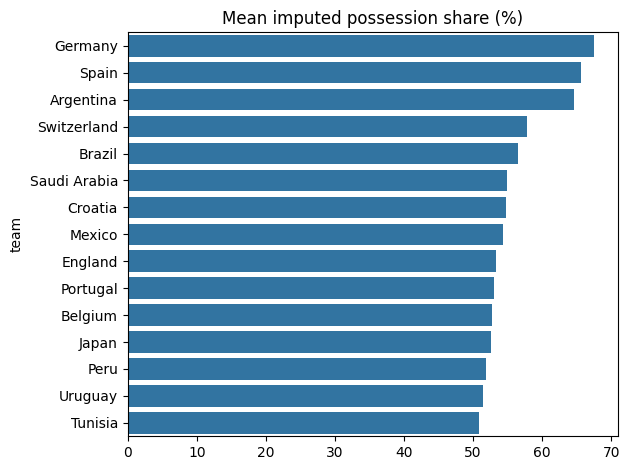

,goals,xg,delta
team,,,
France,14,6.449044,7.550956
Russia,11,4.136802,6.863198
Belgium,16,11.940926,4.059074
Croatia,14,10.072767,3.927233
Portugal,6,3.295829,2.704171
Colombia,6,3.309211,2.690789
England,12,9.529504,2.470496
Japan,6,4.125863,1.874137
Switzerland,5,3.758871,1.241129


In [3]:
poss = tact.dropna(subset=["possession"]).copy()
if not poss.empty:
    top = poss.groupby("team")["possession"].mean().sort_values(ascending=False).head(15)
    sns.barplot(x=top.values, y=top.index, orient="h").set(title="Mean imputed possession share (%)")
    plt.tight_layout()
    plt.show()

home = matches[["match_id", "home_team", "home_score", "away_score"]].rename(
    columns={"home_team": "team"}
)
away = matches[["match_id", "away_team", "home_score", "away_score"]].rename(
    columns={"away_team": "team"}
)
gh = home.assign(goals=home["home_score"])[["match_id", "team", "goals"]]
ga = away.assign(goals=away["away_score"])[["match_id", "team", "goals"]]
goals_long = pd.concat([gh, ga], ignore_index=True)
t_goals = tact.merge(goals_long, on=["match_id", "team"], how="left")
if not t_goals.empty and "xg" in t_goals.columns:
    perf = (
        t_goals.groupby("team")
        .agg(goals=("goals", "sum"), xg=("xg", "sum"))
        .assign(delta=lambda d: d["goals"] - d["xg"])
        .sort_values("delta", ascending=False)
    )
    display(perf.head(10))


## Shots — zones, foot, pressure

StatsBomb pitch: **x → goal**, **y** across width (120×80).

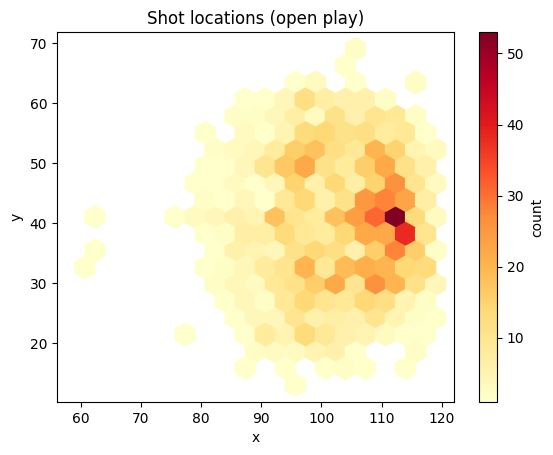

body_part
Head          0.103226
Left Foot     0.081800
Right Foot    0.075152
Other         0.071429
Name: is_goal, dtype: float64

under_pressure
True    0.057751
Name: is_goal, dtype: float64

In [4]:
if not shots.empty:
    fig, ax = plt.subplots()
    hb = ax.hexbin(shots["x"], shots["y"], gridsize=18, cmap="YlOrRd", mincnt=1)
    plt.colorbar(hb, ax=ax, label="count")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Shot locations (open play)")
    plt.show()

    if "body_part" in shots.columns:
        display(shots.groupby("body_part")["is_goal"].mean().sort_values(ascending=False))
    if shots["under_pressure"].notna().any():
        display(shots.groupby("under_pressure")["is_goal"].mean())

## Penalties — outcomes & coarse zones

`zone` is a coarse bin from `end_location` for Week 1; refine for keeper asymmetry later.

In [5]:
if not pens.empty:
    display(pens["scored"].mean())
    if pens["zone"].notna().any():
        display(pens.groupby("zone")["scored"].mean())
    zk = pens["keeper"].fillna("").astype(str).str.strip()
    if zk.ne("").any():
        display(pens.assign(_k=zk).query("_k != ''").groupby("keeper")["scored"].mean().head(10))


np.float64(0.7058823529411765)

zone
mouth_center    0.631579
mouth_high_y    0.631579
mouth_low_y     0.800000
Name: scored, dtype: float64